<a href="https://colab.research.google.com/github/dac012/ValeraSanchezMontes-RL/blob/main/k_brazos/bernoulli.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudio sobre la Cota Teórica de Lai-Robbins

*Description:* El experimento tiene como objetivo encontrar una explicación a por qué no se respeta la cota inferior de Lai-Robbins en el entorno de Bernoulli, para eso, usaremos como comparación el entorno Binomial, aunque podría usarse cualquier otro.

    Authors: David Valera López
             Lucía Sánchez Montes Gómez

    Emails: d.valeralopez1@um.es
            lucia.s1@um.es


In [15]:
# Clonamos el repositorio
#!git clone https://github.com/dac012/ValeraSanchezMontes-RL.git

#%cd ValeraSanchezMontes-RL/k_brazos


## Preparación del entorno


In [ ]:
import sys
sys.path.append('./src')
print(sys.path)

import numpy as np
import pandas as pd
from typing import List

from src.algorithms import Algorithm, EpsilonGreedy
from src.arms import ArmBernoulli, ArmBinomial, Bandit
from src.plotting import plot_regret, plot_arm_statistics


['C:\\Users\\David\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\David\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\David\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\David\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\Users\\David\\Universidad\\Máster\\Asignaturas\\Segundo Cuatrimestre\\Extensiones de Machine Learning\\emlenv', '', 'c:\\Users\\David\\Universidad\\Máster\\Asignaturas\\Segundo Cuatrimestre\\Extensiones de Machine Learning\\emlenv\\Lib\\site-packages', './src', './src', './src', './src']


In [17]:
# Parámetros del experimento

seed = 42 # Fijar la semilla para reproducibilidad
np.random.seed(seed)
np.random.default_rng(seed)

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución de bernoulli
bandit2 = Bandit(arms=ArmBinomial.generate_arms(k, n=20)) # Generar un bandido con k brazos de distribución binomial
print(bandit)
print(bandit2)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")
optimal_arm2 = bandit2.optimal_arm
print(f"Optimal arm: {optimal_arm2 + 1} with expected reward={bandit2.get_expected_value(optimal_arm2)}")

Bandit with 10 arms: ArmBernoulli(p=0.37), ArmBernoulli(p=0.95), ArmBernoulli(p=0.6), ArmBernoulli(p=0.73), ArmBernoulli(p=0.16), ArmBernoulli(p=0.06), ArmBernoulli(p=0.87), ArmBernoulli(p=0.71), ArmBernoulli(p=0.97), ArmBernoulli(p=0.02)
Bandit with 10 arms: ArmBinomial(n=20, p=0.83), ArmBinomial(n=20, p=0.52), ArmBinomial(n=20, p=0.21), ArmBinomial(n=20, p=0.3), ArmBinomial(n=20, p=0.18), ArmBinomial(n=20, p=0.43), ArmBinomial(n=20, p=0.29), ArmBinomial(n=20, p=0.61), ArmBinomial(n=20, p=0.14), ArmBinomial(n=20, p=0.37)
Optimal arm: 9 with expected reward=0.97
Optimal arm: 1 with expected reward=16.599999999999998


## Experimento

Durante la evaluación de los algoritmos en los distintos entornos estocásticos, hemos observado un fenómeno que merece una inspección teórica más profunda. En escenarios de baja varianza como el entorno de Bernoulli, algunas estrategias agresivas o en fases de exploración iniciales lograron mantener su curva de arrepentimiento (*regret*) por debajo de la cota teórica dictada por Lai y Robbins (1985). Sin embargo, al trasladar estos mismos algoritmos a entornos de mayor escala y ruido, como las distribuciones Binomial o Normal, esta cota teórica se comportó como un muro inferior absoluto desde los primeros compases del experimento. 

Para comprender este suceso, es necesario recordar qué representa exactamente esta frontera matemática. El teorema de Lai y Robbins establece que cualquier algoritmo de asignación que sea "uniformemente bueno" sufrirá, inevitablemente, un arrepentimiento esperado $L_T$ que crece de forma logarítmica con el tiempo. Matemáticamente, este límite asintótico viene condicionado por la divergencia de Kullback-Leibler, $l(\mu_i, \mu^*)$, que mide la distancia de información entre la distribución de un brazo subóptimo y la del óptimo. La cota exige que el arrepentimiento cumpla la siguiente inecuación en el límite cuando el tiempo tiende a infinito:

$$L_T \ge \sum_{i:\mu_i < \mu^*} \frac{\mu^* - \mu_i}{l(\mu_i, \mu^*)} \ln(T)$$

El propósito de este experimento aislado es ilustrar visualmente este aparente "incumplimiento" de la cota matemática. Para ello, vamos a recrear un entorno controlado donde calcularemos de forma analítica y exacta la divergencia de Kullback-Leibler para los brazos subóptimos. A partir de este cálculo, analizaremos lo que está pasando exactamente..

In [18]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Ejecuta la simulación de los algoritmos sobre múltiples repeticiones independientes para extraer las métricas de rendimiento.

    :param bandit: Instancia del entorno de bandido multibrazo a evaluar.
    :param algorithms: Lista de algoritmos de aprendizaje que se compararán en el experimento.
    :param steps: Número total de pasos de tiempo (horizonte) por cada ejecución.
    :param runs: Número de repeticiones independientes del experimento para promediar los resultados.

    :return: Una tupla con las matrices promediadas de recompensas, selecciones óptimas, regret acumulado y estadísticas finales.
    """

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regret = np.zeros((len(algorithms), steps)) # Matriz para almacenar el regret instantáneo por algoritmo y paso de tiempo.

    # Creamos acumuladores para calcular la media y el conteo total al final
    stats_accumulator = [
        {arm_i: {'sum_rewards': 0.0, 'count': 0} for arm_i in range(len(bandit.arms))} 
        for _ in algorithms
    ]

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                optimal_value = bandit.get_expected_value(optimal_arm) # Obtenemos el optimal value del paso
                regret[idx, step] += optimal_value - reward # Acumular el regret instantáneo: diferencia entre la mejor recompensa esperada y la obtenida.


                # Modificar optimal_selections cuando el brazo elegido se corresponda con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm:
                    optimal_selections[idx][step] += 1.0

                # Acumular las recompensas y conteos para cada brazo y algoritmo
                stats_accumulator[idx][chosen_arm]['sum_rewards'] += reward
                stats_accumulator[idx][chosen_arm]['count'] += 1


    rewards /= runs

    # Calcular el porcentaje de selecciones óptimas y almacenar en optimal_selections
    optimal_selections /= runs
    optimal_selections *= 100

    # Promediamos el regret instantáneo sobre el número total de ejecuciones (runs)
    # para obtener el regret medio por algoritmo y paso de tiempo.
    regret /= runs
    # Calculamos el regret acumulado como la suma acumulada del regret instantáneo
    # a lo largo del tiempo. Tiene que ser el regret acumulado por que es lo que nos dice la teoria del problema de los bandidos
    regret_accumulated = np.cumsum(regret, axis=1)

    # Convertimos los acumuladores en estadísticas finales para cada brazo y algoritmo
    final_arm_stats = []
    for algo_stats in stats_accumulator:
        formatted_stats = {}
        for arm_id, data in algo_stats.items():
            total_count = data['count']
            # Calcular media (evitar división por cero)
            avg = data['sum_rewards'] / total_count if total_count > 0 else 0.0
            
            formatted_stats[arm_id] = {
                'avg_reward': avg,
                'times_selected': total_count,
                'optimal_arm': 1 if arm_id == optimal_arm else 0
            }
        final_arm_stats.append(formatted_stats)

    return rewards, optimal_selections, regret_accumulated, final_arm_stats


In [19]:
def calculate_kl_divergence(arm_type, mu_subopt, mu_opt, params):
    """
    Calcula la Divergencia de Kullback-Leibler I(f, g) entre un brazo sub-óptimo y el óptimo.
    
    :param arm_type: Tipo de distribución ('Normal' o 'Binomial').
    :param mu_subopt: Valor esperado del brazo sub-óptimo (f).
    :param mu_opt: Valor esperado del brazo óptimo (g).
    :param params: Diccionario con parámetros adicionales (sigma para Normal, n para Binomial).

    :return: La divergencia KL I(f, g) correspondiente al tipo de brazo.
    """
    if arm_type == 'Normal':
        sigma = params.get('sigma')
        
        # Fórmula KL para Normales:
        return (mu_subopt - mu_opt)**2 / (2 * sigma**2)
    
    elif arm_type == 'Binomial':
        n = params.get('n')
    
        # Calculamos la información necesaria
        p_subopt = mu_subopt / n
        p_opt = mu_opt / n
        
        # Clip para evitar log(0) o divisiones por cero
        eps = 1e-15
        p = np.clip(p_subopt, eps, 1 - eps)
        q = np.clip(p_opt, eps, 1 - eps)
        
        # Fórmula KL para Bernoulli:
        kl_bernoulli = p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))
        
        # La KL de una Binomial(n, p) es n veces la de una Bernoulli(p)
        return n * kl_bernoulli

def get_theoretical_regret_curve(bandit: Bandit, steps: int):
    """
    Calcula la cota de Lai & Robbins adaptada automáticamente al tipo de Bandido.

    :param bandit: Instancia del Bandit para el cual se quiere calcular la curva de regret teórica.
    :param steps: Número de pasos de tiempo para los cuales se quiere calcular la curva.

    :return: Un array con la curva de regret teórica para cada paso de tiempo.
    """
    optimal_arm = bandit.optimal_arm
    mu_star = bandit.get_expected_value(optimal_arm)
    
    # Miramos el primer brazo para determinar el tipo de todo el bandido
    sample_arm = bandit.arms[0]
    
    # Detectamos tipo basado en el nombre de la clase
    arm_class_name = type(sample_arm).__name__
    
    params = {}
    if 'Normal' in arm_class_name:
        arm_type = 'Normal'
        # Buscamos el atributo sigma
        params['sigma'] = getattr(sample_arm, 'sigma')
        
    elif 'Binomial' in arm_class_name or 'Bernoulli' in arm_class_name:
        arm_type = 'Binomial'
        # Buscamos n.
        params['n'] = getattr(sample_arm, 'n', 1)

    # Cálculo del sumatorio
    constant_sum = 0
    
    for arm_index in range(len(bandit.arms)):
        if arm_index != optimal_arm:
            mu_a = bandit.get_expected_value(arm_index)
            delta = mu_star - mu_a
            
            # Solo sumamos si el brazo es peor (delta > 0)
            if delta > 1e-10: 
                # Calculamos el denominador I(mu_a, mu_star)
                kl = calculate_kl_divergence(arm_type, mu_a, mu_star, params)
                
                # Lai & Robbins: Suma de (Delta / KL)
                if kl > 0:
                    constant_sum += delta / kl
                    
    # C(t) = Constante * ln(t)
    time_steps = np.arange(1, steps + 1)
    theoretical_regret = constant_sum * np.log(time_steps)
    
    return theoretical_regret

# Cálculo de la curva de regret teórica para el bandido dado y el número de pasos
theoretical_regret = get_theoretical_regret_curve(bandit, steps)


### Ejecución del experimento

In [20]:
# Definimos los algoritmos a comparar. En este caso son 5 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms_greedy = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1), EpsilonGreedy(k=k, epsilon=0.3), EpsilonGreedy(k=k, epsilon=0.5)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards_greedy, optimal_selections_greedy, regret_accumulated_greedy, arm_stats_greedy = run_experiment(bandit, algorithms_greedy, steps, runs)
rewards_greedy2, optimal_selections_greedy2, regret_accumulated_greedy2, arm_stats_greedy2 = run_experiment(bandit2, algorithms_greedy, steps, runs)

### Gráficas de regret acumulado vs pasos de tiempo

En estas dos gráficas observamos dicha anomalía, el cómo se cumple la cota para el entorno Binomial pero no para el de Bernoulli.

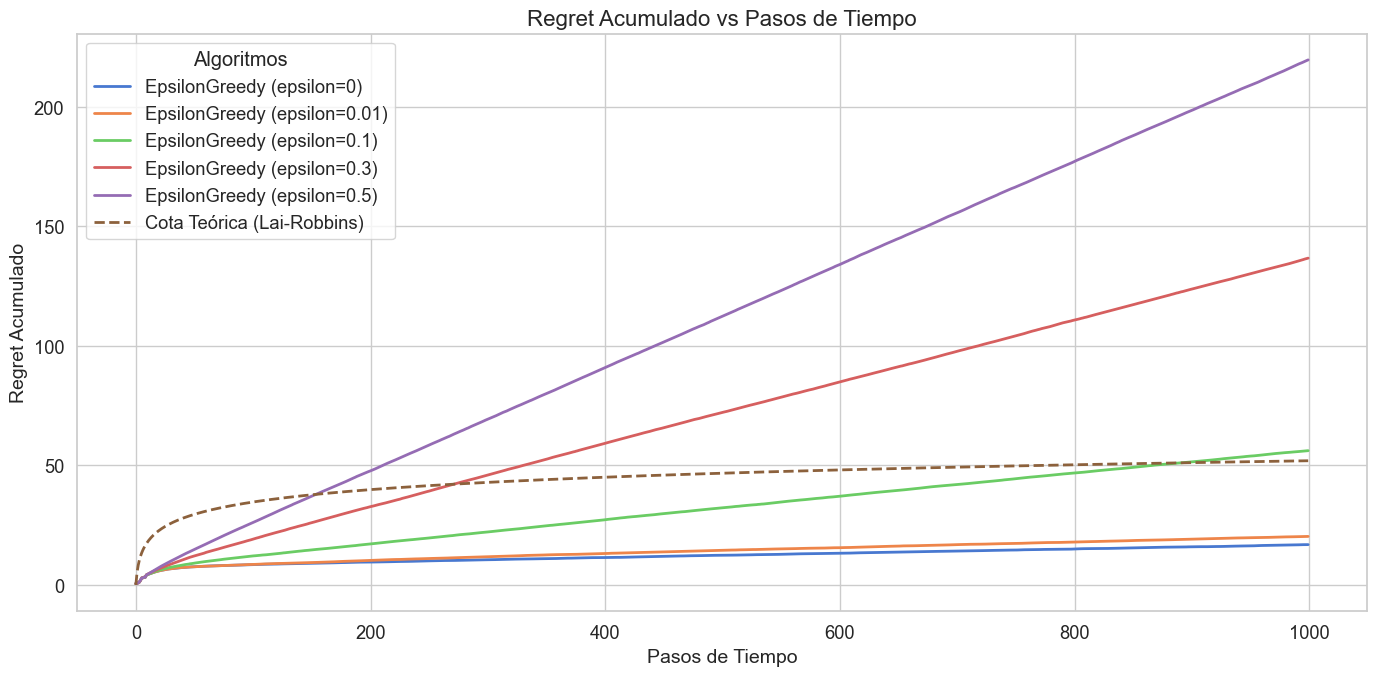

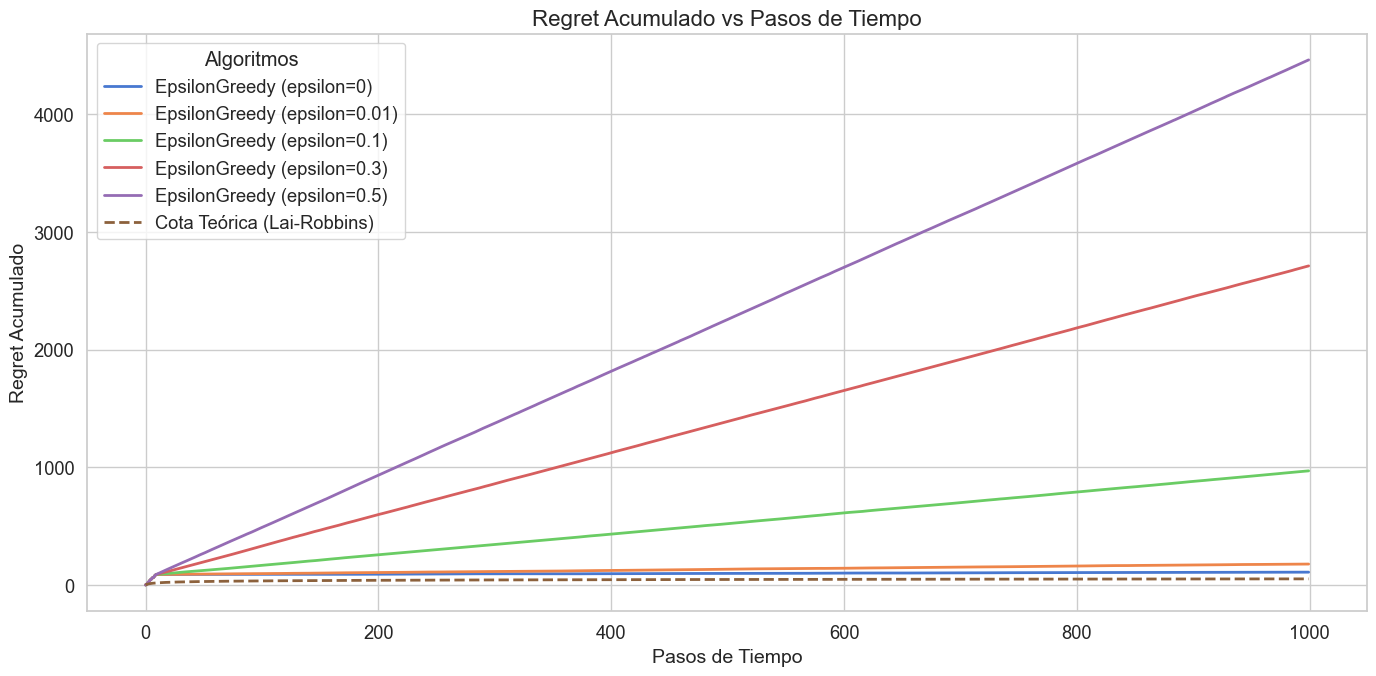

In [21]:
plot_regret(steps, regret_accumulated_greedy, algorithms_greedy, (theoretical_regret, "Cota Teórica (Lai-Robbins)"))
plot_regret(steps, regret_accumulated_greedy2, algorithms_greedy, (theoretical_regret, "Cota Teórica (Lai-Robbins)"))

### Cálculo de número de tiradas esperadas para cada brazo subóptimo

In [ ]:
def get_expected_pulls_per_arm(bandit, steps):
    """
    Calcula el número de tiradas esperadas mínimas para cada brazo subóptimo
    según la cota de Lai & Robbins.
    """
    optimal_arm = bandit.optimal_arm
    mu_star = bandit.get_expected_value(optimal_arm)
    
    # Detectamos tipo de brazo usando la misma lógica que en tu código
    sample_arm = bandit.arms[0]
    arm_class_name = type(sample_arm).__name__
    params = {}
    
    if 'Normal' in arm_class_name:
        arm_type = 'Normal'
        params['sigma'] = getattr(sample_arm, 'sigma')
    elif 'Binomial' in arm_class_name or 'Bernoulli' in arm_class_name:
        arm_type = 'Binomial'
        params['n'] = getattr(sample_arm, 'n', 1)
        
    ln_t = np.log(steps)
    results = []
    
    for a in range(len(bandit.arms)):
        mu_a = bandit.get_expected_value(a)
        
        # Si es el brazo óptimo, no hay límite en las tiradas
        if a == optimal_arm:
            results.append({'Brazo': a+1, 'Probabilidad': mu_a, 'Divergencia KL': '-', 'Tiradas Esperadas': '-'})
            continue
            
        # Usamos TU función para calcular la KL
        kl = calculate_kl_divergence(arm_type, mu_a, mu_star, params)
        
        # Calculamos ln(t) / KL
        expected_pulls = ln_t / kl if kl > 0 else 0
        
        results.append({
            'Brazo': a+1,
            'Probabilidad': mu_a,
            'Divergencia KL': round(kl, 4),
            'Tiradas Esperadas': round(expected_pulls, 2)
        })
        
    return pd.DataFrame(results)

# Ejecutamos para t=1000
df_tiradas = get_expected_pulls_per_arm(bandit, steps=1000)
display(df_tiradas)
df_tiradas = get_expected_pulls_per_arm(bandit2, steps=1000)
display(df_tiradas)

,Brazo,Probabilidad,Divergencia KL,Tiradas Esperadas
0,1,0.37,1.5614,4.42
1,2,0.95,0.0057,1201.58
2,3,0.60,0.7479,9.24
3,4,0.73,0.3857,17.91
4,5,0.16,2.5107,2.75
5,6,0.06,3.071,2.25
6,7,0.87,0.096,71.98
7,8,0.71,0.4364,15.83
8,9,0.97,-,-
9,10,0.02,3.339,2.07


,Brazo,Probabilidad,Divergencia KL,Tiradas Esperadas
0,1,16.6,-,-
1,2,10.4,5.1017,1.35
2,3,4.2,18.5004,0.37
3,4,6.0,13.7081,0.5
4,5,3.6,20.303,0.34
5,6,8.6,8.1364,0.85
6,7,5.8,14.1995,0.49
7,8,12.2,2.7195,2.54
8,9,2.8,22.9001,0.3
9,10,7.4,10.5264,0.66


### Gráficas de selección de brazos en histogramas

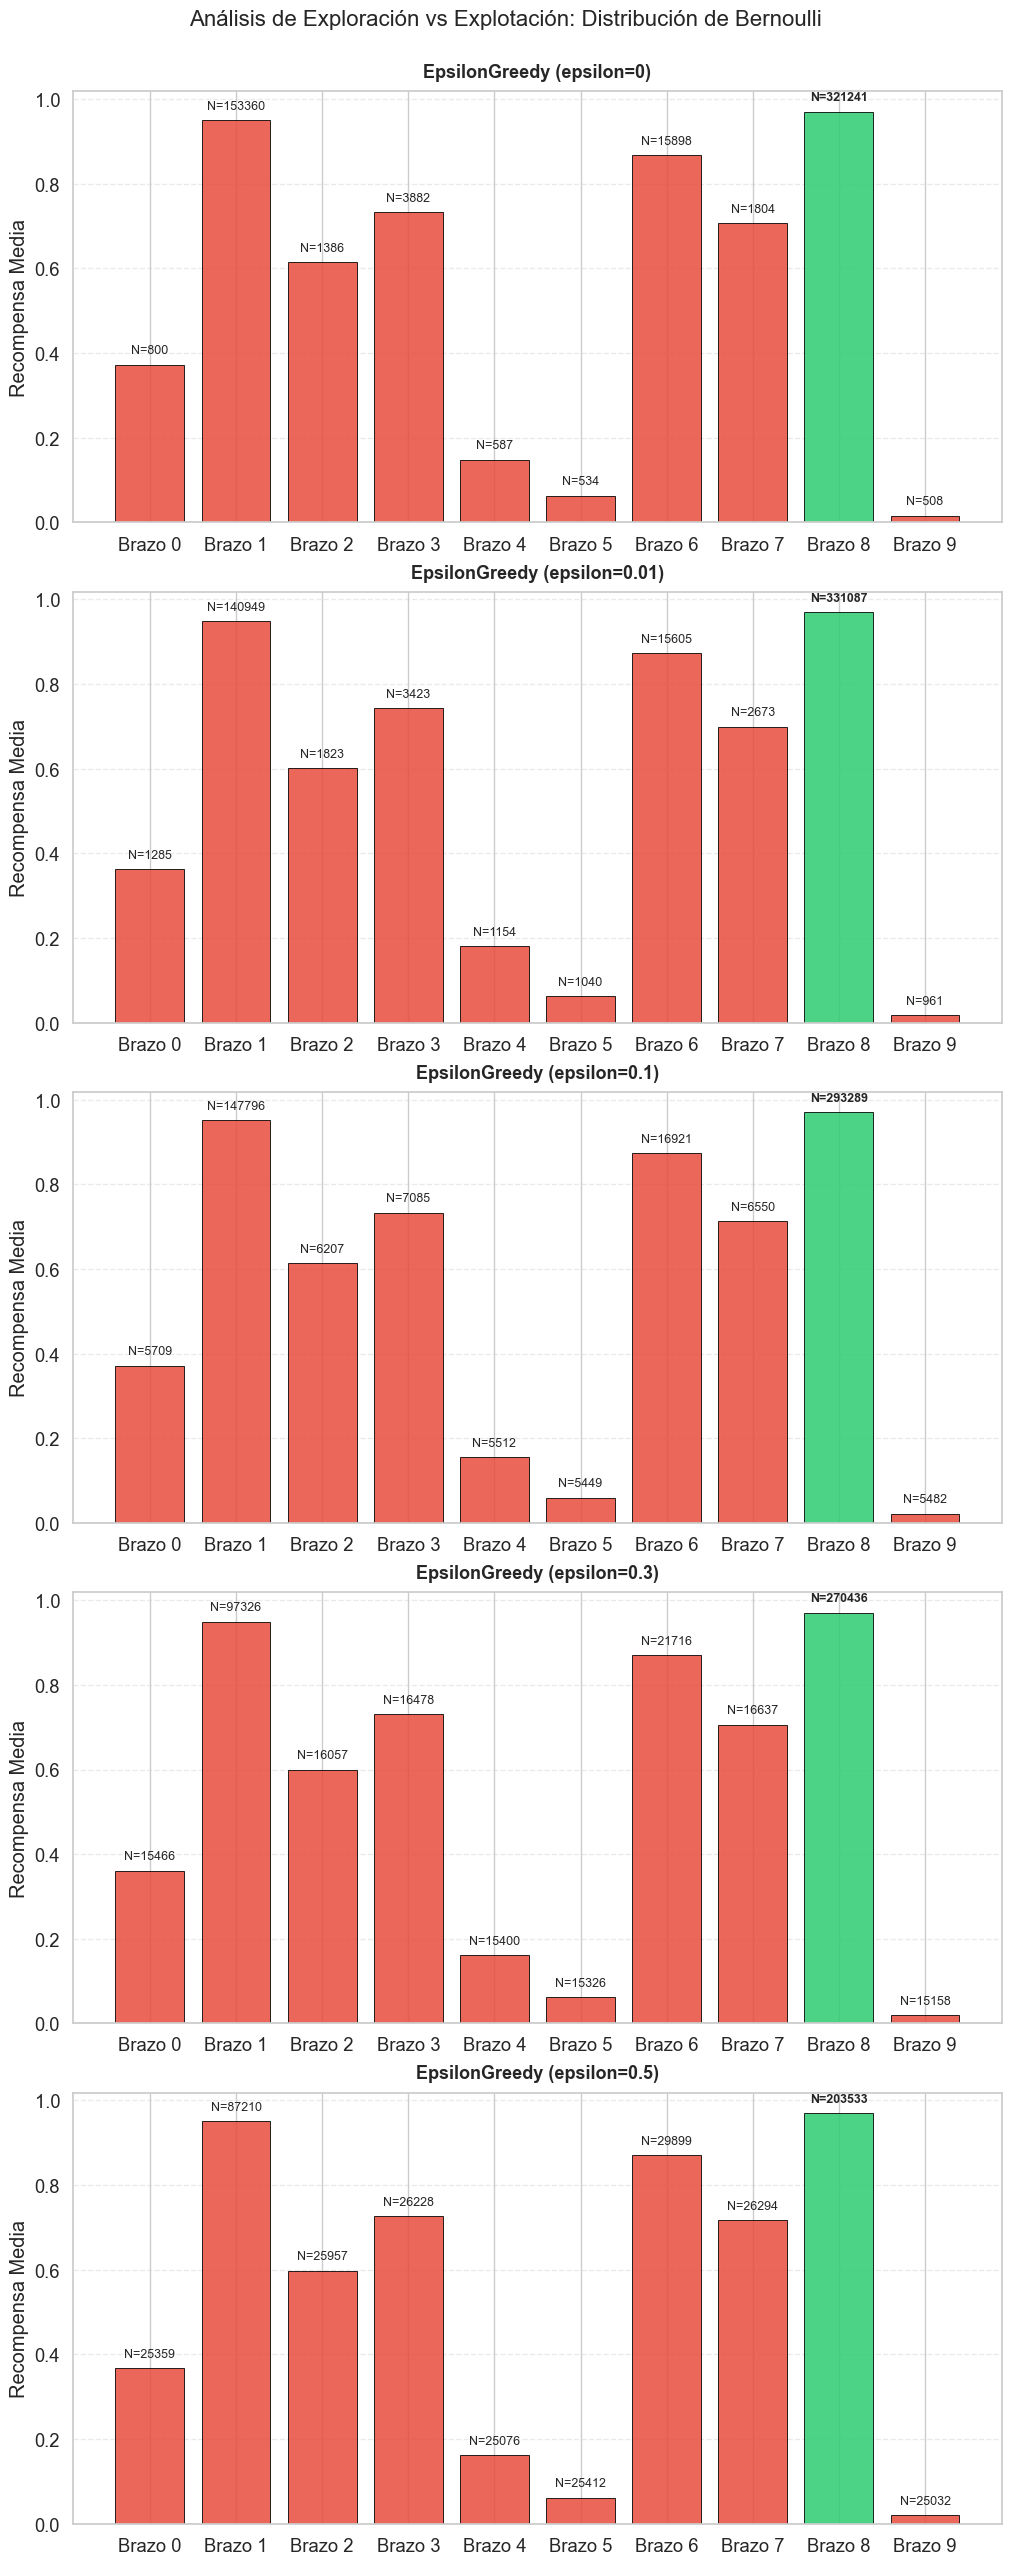

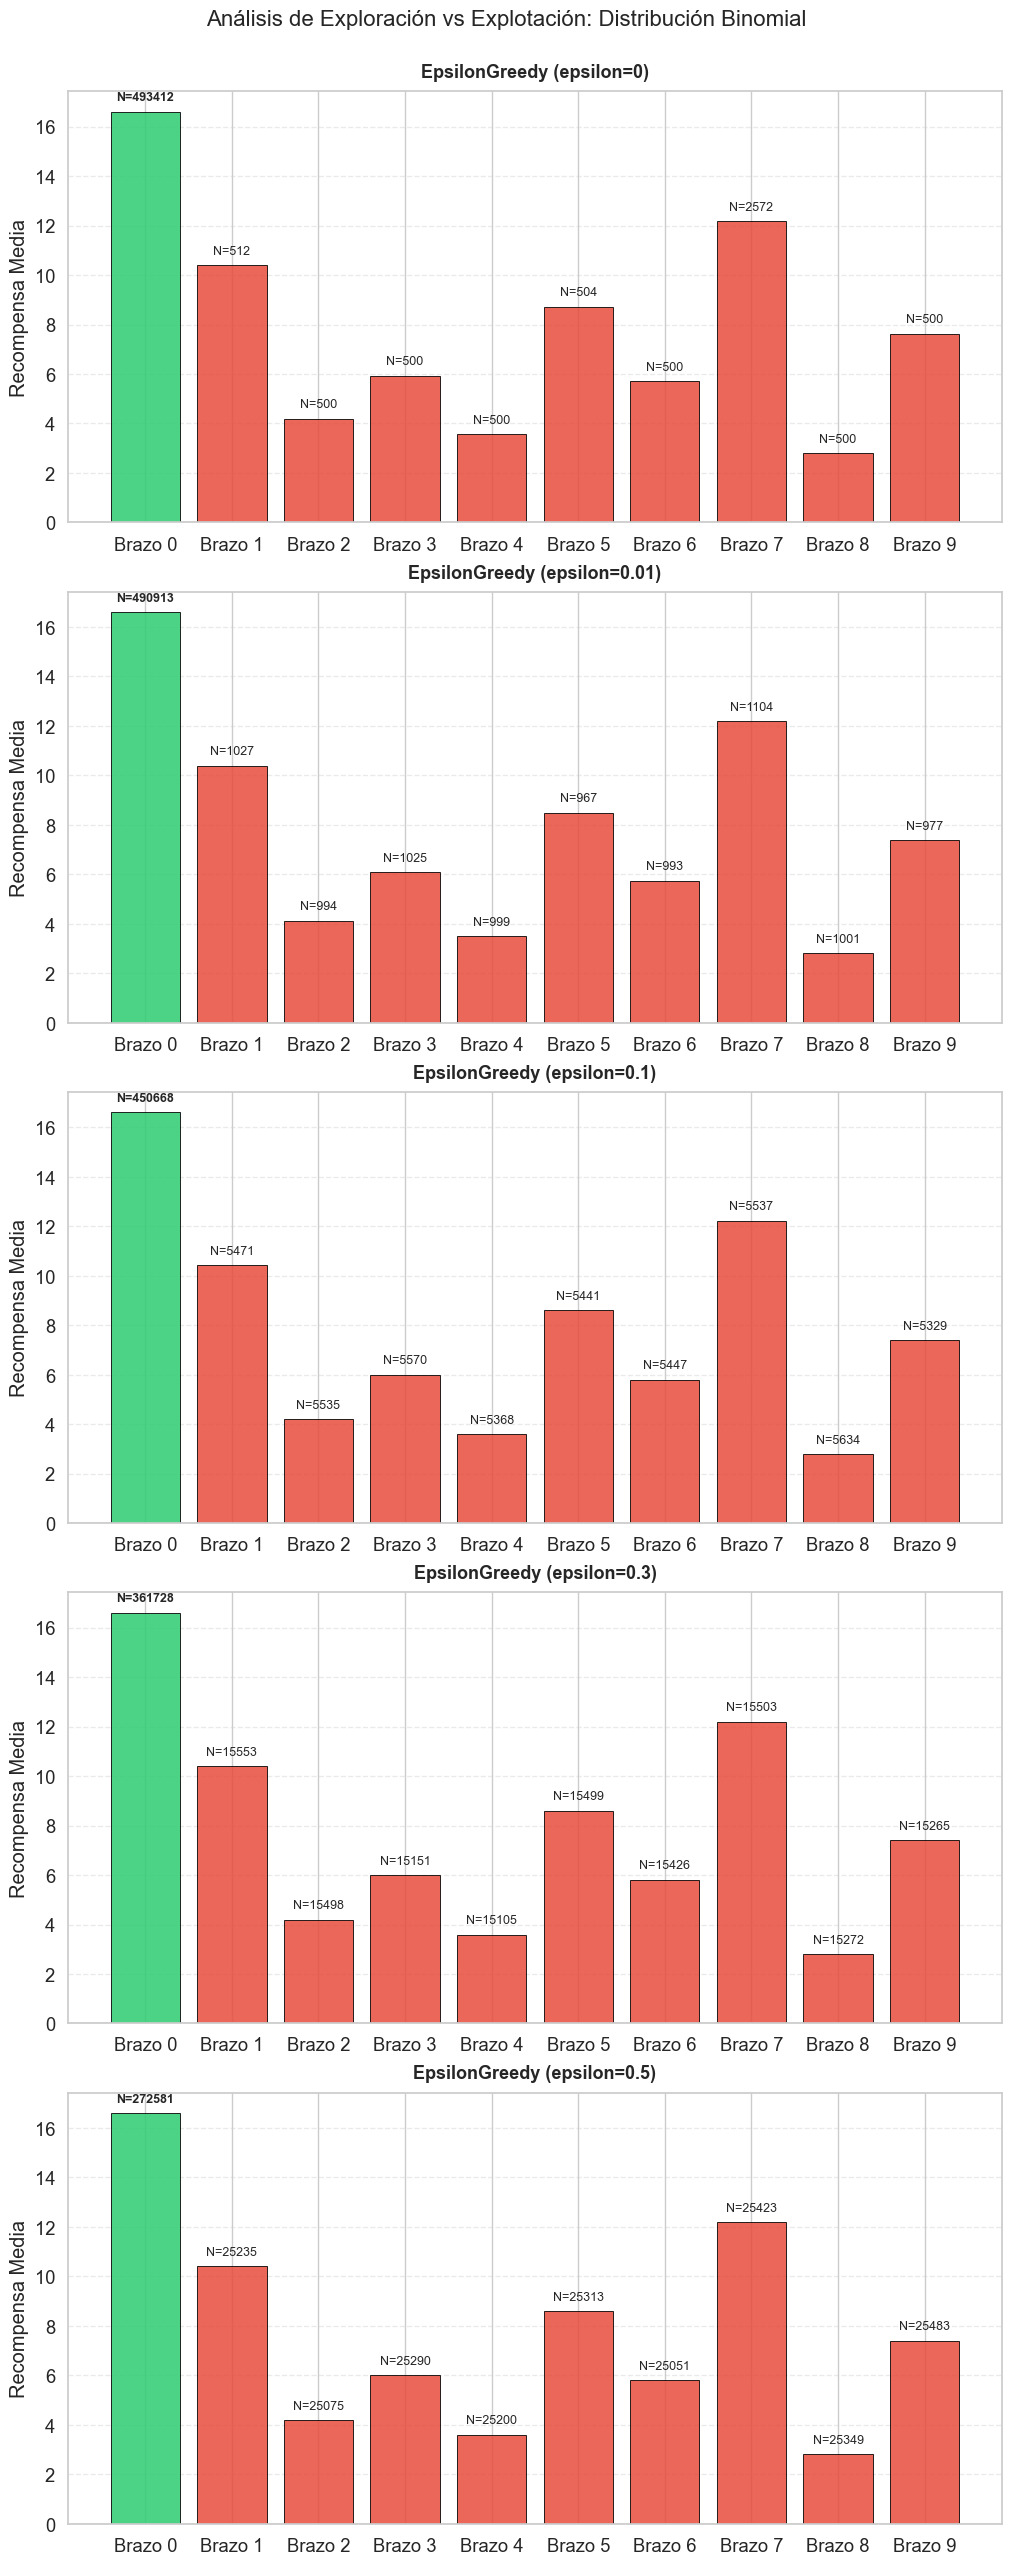

In [23]:
plot_arm_statistics(arm_stats_greedy, algorithms_greedy, experiment_label="Distribución de Bernoulli")
plot_arm_statistics(arm_stats_greedy2, algorithms_greedy, experiment_label="Distribución Binomial")

### Resultados del Experimento: Análisis del Requisito Exploratorio

Tras ejecutar la simulación controlada para los entornos de Bernoulli y Binomial, hemos extraído y tabulado el número esperado empírico de selecciones de cada brazo ($\mathbb{E}[N_i]$) frente al límite inferior teórico exigido por el teorema de Lai-Robbins, definido como $\frac{\ln(T)}{KL(\mu_i, \mu^*)}$. Los resultados obtenidos revelan el motivo exacto por el cual la cota de arrepentimiento parece vulnerarse a corto plazo en las gráficas generales.

#### Análisis del Entorno Bernoulli
Al observar los datos correspondientes a la distribución de Bernoulli, queda claro que el algoritmo no cumple con la premisa fundamental del teorema en este horizonte de tiempo finito. Para que la cota inferior de arrepentimiento sea aplicable, el algoritmo debería explorar los brazos subóptimos un número mínimo de veces. 

Sin embargo, los datos demuestran un claro déficit exploratorio. Tomando como ejemplo el primer algoritmo y fijándonos en el Brazo 0: el agente lo selecciona **800** veces en total a lo largo de las **500** ejecuciones independientes (lo que equivale a **1.6** selecciones medias por ejecución). Por el contrario, la teoría exige un mínimo de **4.42** selecciones por ejecución para garantizar la eficiencia asintótica. Este déficit se repite de forma consistente en el resto de los brazos subóptimos analizados.

Al no satisfacerse el requisito de exploración mínimo ($\mathbb{E}[n_i] \ge \frac{\ln(T)}{I(\mu_i, \mu^*)}$), la consecuencia directa sobre el arrepentimiento total ($L_T \ge \text{Cte} \cdot \ln(T)$) pierde su obligatoriedad durante la simulación. El algoritmo explora menos de lo exigido por la cota, lo que le permite acumular temporalmente un arrepentimiento inferior al límite teórico.

#### Análisis del Entorno Binomial
Al trasladar el experimento al entorno Binomial, la situación se invierte por completo, lo que valida nuestra hipótesis inicial sobre la dependencia del requisito exploratorio.

Tomando como referencia el Brazo 6 del primer algoritmo, el límite teórico establece que se espera un mínimo de **0.49** selecciones por ejecución. Al contrastar este valor con el histograma empírico, observamos que el brazo se selecciona un total de **500** veces a lo largo del experimento (es decir, **1** vez por ejecución). Dado que **1** es estrictamente mayor que **0.49**, el requisito de exploración matemática se satisface holgadamente. Al igual que en el caso anterior, esta dinámica de cumplimiento se mantiene constante para cualquier otro brazo que escojamos en este entorno.

#### Conclusión
El contraste entre ambos experimentos demuestra que la validez de la cota de Lai-Robbins es dependiente del cumplimiento de su premisa de exploración mínima. La clave de que este fenómeno ocurra de forma asimétrica entre distribuciones radica en la magnitud de la divergencia de Kullback-Leibler ($KL$).

En entornos como el Binomial, la divergencia $KL$ crece proporcionalmente a los parámetros de la distribución, generando un denominador muy grande que reduce el requisito exploratorio teórico a valores residuales (por ejemplo, $0.49$). Dado que cualquier algoritmo necesita inicializar probando cada brazo al menos una vez, este umbral matemático es superado de forma inmediata, activando la cota teórica y haciéndola actuar como un límite inferior.

Por el contrario, en entornos de baja varianza informativa como Bernoulli, la reducida divergencia $KL$ exige una mayor carga de prueba estadística (ej. $4.42$ selecciones) para descartar un brazo con certeza asintótica. En horizontes de tiempo finito, los algoritmos interpretan esta exigencia tomando decisiones tempranas basadas en penalizaciones: una sola recompensa nula hunde el valor estimado $Q(a)$ del brazo, provocando que el agente lo descarte casi al instante. Esta subexploración genera una ilusión gráfica de "batir" la cota de arrepentimiento, ya que el agente ahorra intentos subóptimos a corto plazo asumiendo un mayor riesgo de caer en óptimos locales.

En definitiva, la cota matemática no se vulnera; simplemente, la teoría asume un horizonte infinito ($T \rightarrow \infty$) donde las decisiones precipitadas terminan penalizando, mientras que en simulaciones finitas, las condiciones para su aplicación asintótica no siempre se alcanzan.